# 02 — Sentiment Classification with BERT
**Project**: Automated Customer Reviews — IronHack

---

## Goal
Use a pretrained BERT model to classify each review as **positive**, **neutral**, or **negative** based on the review text alone — no manual rules, no star ratings.

We then evaluate how well the model performs by comparing its predictions to the `ground_truth` labels we created in notebook 01.

---

## Why this BERT model?

We use **`nlptown/bert-base-multilingual-uncased-sentiment`** for the following reasons:

| Reason | Detail |
|--------|--------|
| ✅ Trained on product reviews | Pretrained on Amazon & Yelp reviews — exactly our domain |
| ✅ No fine-tuning needed | Already understands product sentiment out of the box |
| ✅ Multilingual | Handles English and other languages in the dataset |
| ✅ Direct star output | Predicts 1–5 stars from text → we map to our 3 classes |
| ✅ Lightweight | Runs on CPU — no GPU required |

Since our dataset consists of Amazon product reviews, this model is the most natural fit without any additional training.

---

## Evaluation Metrics

| Metric | What it tells us |
|--------|------------------|
| **Accuracy** | % of reviews classified correctly overall |
| **Precision** | Of all reviews predicted as class X, how many were actually X |
| **Recall** | Of all actual class X reviews, how many did the model find |
| **F1-score** | Balance between precision and recall — most important for imbalanced data |
| **Confusion Matrix** | Visual overview of where the model makes mistakes |

> **Note**: ROUGE and BLEU are not used here — those metrics are for text generation and will be used in notebook 04 (Summarization).

---

## 1. Imports

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.15)

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/plots',     exist_ok=True)

LABEL_ORDER  = ['positive', 'neutral', 'negative']
PALETTE      = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}

print('✅ Imports done')

✅ Imports done


## 2. Load Clean Dataset

In [3]:
DATA_PATH = '/Users/domiendarmont/Desktop/project_rev.aggre./data/data_processedreviews_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.columns.tolist()}')
df.head(5)

Rows    : 46,169
Columns : ['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth']


,product_name,brand,rating,review_title,review_text,ground_truth
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Kindle,This product so far has not disappointed. My c...,positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,very fast,great for beginner or experienced person. Boug...,positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,4,Good!!!,I've had my Fire HD 8 two weeks now and I love...,positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,5,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,positive


In [4]:
print(df['ground_truth'].value_counts())

ground_truth
positive    42321
neutral      2029
negative     1819
Name: count, dtype: int64


## 3. Prepare Input Text

We combine `review_title` and `review_text` into one input string for BERT.  
The title often contains a strong sentiment signal — combining both gives the model more context.

In [5]:
def build_input_text(row: pd.Series) -> str:
    """Combine review title and review text into one BERT input string."""
    title = str(row['review_title']).strip() if pd.notna(row['review_title']) else ''
    text  = str(row['review_text']).strip()
    if title:
        return f'{title}. {text}'
    return text

df['input_text'] = df.apply(build_input_text, axis=1)

# Truncate to 512 characters — BERT has a 512 token limit
# Characters are not tokens, but this is a safe approximation
df['input_text'] = df['input_text'].str[:512]

print('Input text sample:')
print(df['input_text'].iloc[0])

Input text sample:
Kindle. This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.


## 4. Load the BERT Model

We use the HuggingFace `pipeline` — this handles tokenization and inference in one call.  
The model outputs a star rating (1–5) based on the text, which we map to our 3 sentiment classes.

In [6]:
MODEL_NAME = 'nlptown/bert-base-multilingual-uncased-sentiment'

print(f'Loading model: {MODEL_NAME}')
print('This may take a moment, please be patience (downloads ~700MB)...\n')

sentiment_pipeline = pipeline(
    task          = 'text-classification',
    model         = MODEL_NAME,
    truncation    = True,
    max_length    = 512,
    device        = -1,   # -1 = CPU · 0 = GPU if available
)

print('✅ Model loaded successfully')

Loading model: nlptown/bert-base-multilingual-uncased-sentiment
This may take a moment, please be patience (downloads ~700MB)...



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded successfully


In [7]:
print(df.columns.tolist())

['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth', 'input_text']


## 5. Run BERT Predictions

BERT returns a star label like `"3 stars"` — we map that to our 3 classes:

| BERT output | Our label |
|-------------|----------|
| 1 star · 2 stars | `negative` |
| 3 stars | `neutral` |
| 4 stars · 5 stars | `positive` |

> ⏱️ **Runtime note**: Running BERT on thousands of reviews takes time on CPU.  
> We use a sample of 2000 reviews to keep it manageable. Increase `SAMPLE_SIZE` if you have more time or a GPU.

In [8]:
def map_bert_label_to_sentiment(bert_label: str) -> str:
    """Map BERT star output (e.g. '3 stars') to positive/neutral/negative."""
    stars = int(bert_label.split()[0])
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

from sklearn.model_selection import train_test_split

# ── Train/test split ─────────────────────────────────────────
# 80% train · 20% test — stratified to keep class balance
RANDOM_SEED = 42
df_train_split, df_test = train_test_split(
    df,
    test_size    = 0.2,
    stratify     = df['ground_truth'],
    random_state = RANDOM_SEED
)

print(f'Train set : {len(df_train_split):,} reviews')
print(f'Test set  : {len(df_test):,} reviews')



# ── Balanced sample from test set for evaluation ─────────────
# Equal reviews per class for fair evaluation
n_per_class = 300
groups = []
for label in ['positive', 'neutral', 'negative']:
    group = df_test[df_test['ground_truth'] == label].sample(
        n=min(n_per_class, len(df_test[df_test['ground_truth'] == label])),
        random_state=RANDOM_SEED
    )
    groups.append(group)

df_sample = pd.concat(groups, ignore_index=True).copy()

print(f'\nEval sample : {len(df_sample):,} reviews')
print(f'Distribution:')
print(df_sample['ground_truth'].value_counts())

# ── Run BERT predictions ─────────────────────────────────────
BATCH_SIZE = 32
texts      = df_sample['input_text'].tolist()
raw_preds  = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='BERT inference'):
    batch       = texts[i : i + BATCH_SIZE]
    batch_preds = sentiment_pipeline(batch)
    raw_preds.extend(batch_preds)

df_sample['bert_sentiment']  = [
    map_bert_label_to_sentiment(pred['label']) for pred in raw_preds
]
df_sample['bert_confidence'] = [pred['score'] for pred in raw_preds]

print(f'\n✅ Predictions done')
print(df_sample[['review_text', 'ground_truth', 'bert_sentiment', 'bert_confidence']].head(5))

Train set : 36,935 reviews
Test set  : 9,234 reviews

Eval sample : 900 reviews
Distribution:
ground_truth
positive    300
neutral     300
negative    300
Name: count, dtype: int64


BERT inference: 100%|██████████| 29/29 [00:16<00:00,  1.72it/s]


✅ Predictions done
                                         review_text ground_truth  \
0  This is very easy to use and lightweight. Very...     positive   
1  I bought this for my grandson and he likes it ...     positive   
2        They were just what we expected and needed.     positive   
3  Really fun and nifty device...we use it for se...     positive   
4  Simple to set up. My husband isn't tech-savvy,...     positive   

  bert_sentiment  bert_confidence  
0       positive         0.820435  
1       positive         0.746007  
2       positive         0.994816  
3       positive         0.678506  
4       positive         0.525669  


## 6. Evaluation

We compare `bert_sentiment` (what BERT predicted) against `ground_truth` (what the star rating says).

In [9]:
y_true = df_sample['ground_truth']
y_pred = df_sample['bert_sentiment']

accuracy = accuracy_score(y_true, y_pred)

print('=' * 50)
print(f'  Overall Accuracy : {accuracy:.1%}')
print('=' * 50)
print()
print('Per-class metrics (Precision · Recall · F1):')
print(classification_report(y_true, y_pred, target_names=LABEL_ORDER, digits=3))

  Overall Accuracy : 77.8%

Per-class metrics (Precision · Recall · F1):
              precision    recall  f1-score   support

    positive      0.814     0.843     0.828       300
     neutral      0.809     0.523     0.636       300
    negative      0.734     0.967     0.835       300

    accuracy                          0.778       900
   macro avg      0.786     0.778     0.766       900
weighted avg      0.786     0.778     0.766       900



## 7. Visualisations

Two focused plots:
1. **Confusion Matrix** — where does BERT make mistakes?
2. **F1-score per class** — how well does it handle each sentiment?

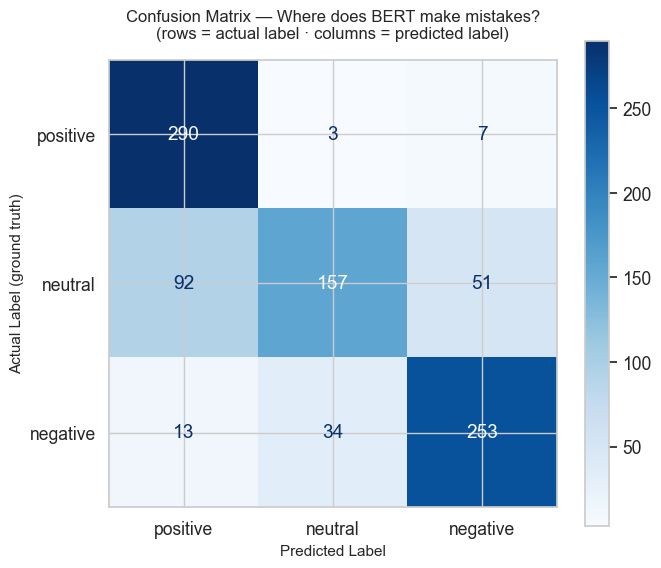

Insight: Off-diagonal cells = mistakes. Large off-diagonal numbers = systematic errors.


In [10]:
# ── Plot 1: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
disp.plot(
    ax            = ax,
    colorbar      = True,
    cmap          = 'Blues',
    values_format = 'd'
)

ax.set_title(
    'Confusion Matrix — Where does BERT make mistakes?\n'
    '(rows = actual label · columns = predicted label)',
    fontsize=12, pad=15
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label (ground truth)', fontsize=11)

plt.tight_layout()
plt.savefig('../data/plots/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Off-diagonal cells = mistakes. Large off-diagonal numbers = systematic errors.')

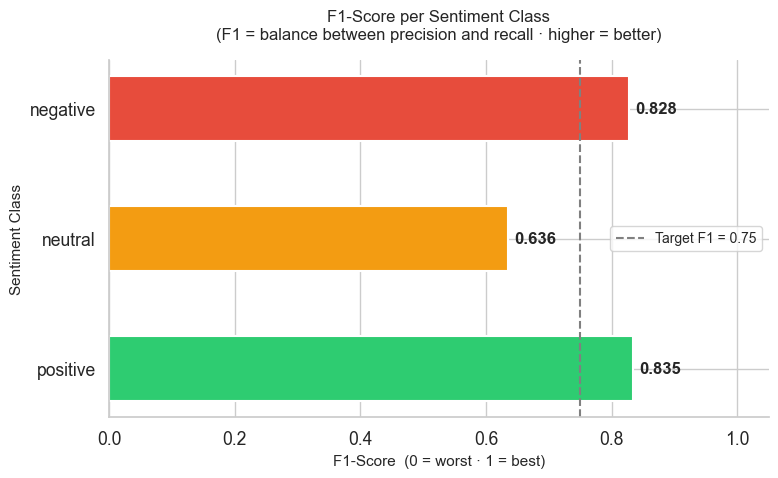

Insight: Low F1 on neutral is expected — neutral reviews are hardest to classify.


In [11]:
# ── Plot 2: F1-score per Sentiment Class ────────────────────
from sklearn.metrics import f1_score

f1_scores = f1_score(y_true, y_pred, labels=LABEL_ORDER, average=None)
f1_df     = pd.DataFrame({'sentiment': LABEL_ORDER, 'f1_score': f1_scores})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    f1_df['sentiment'], f1_df['f1_score'],
    color=[PALETTE[l] for l in LABEL_ORDER],
    edgecolor='white', linewidth=1.5, height=0.5
)

# Add score label on each bar
for bar, score in zip(bars, f1_scores):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{score:.3f}', va='center', fontsize=12, fontweight='bold'
    )

# Reference line at 0.75 — our minimum acceptable F1
ax.axvline(x=0.75, color='grey', linestyle='--', linewidth=1.5, label='Target F1 = 0.75')
ax.set_xlim(0, 1.05)
ax.set_title(
    'F1-Score per Sentiment Class\n'
    '(F1 = balance between precision and recall · higher = better)',
    fontsize=12, pad=15
)
ax.set_xlabel('F1-Score  (0 = worst · 1 = best)', fontsize=11)
ax.set_ylabel('Sentiment Class', fontsize=11)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('../data/plots/05_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Low F1 on neutral is expected — neutral reviews are hardest to classify.')

## 8. Save Results

We add the BERT predictions back to the full dataset and save it.  
The `bert_sentiment` column will be used in notebook 04 (Summarization) to filter by sentiment.

In [12]:
# Merge BERT predictions back onto the full dataframe
df_results = df.merge(
    df_sample[['input_text', 'bert_sentiment', 'bert_confidence']],
    left_on  = df['input_text'] if 'input_text' in df.columns else df.apply(build_input_text, axis=1),
    right_on = df_sample['input_text'],
    how      = 'left'
)

# Simpler: just save the sample with predictions
OUTPUT_PATH = '../data/processed/classified_reviews.csv'
df_sample.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Results saved to : {OUTPUT_PATH}')
print(f'   Rows    : {len(df_sample):,}')
print(f'   Columns : {df_sample.columns.tolist()}')

✅ Results saved to : ../data/processed/classified_reviews.csv
   Rows    : 900
   Columns : ['product_name', 'brand', 'rating', 'review_title', 'review_text', 'ground_truth', 'input_text', 'bert_sentiment', 'bert_confidence']


## 9. Summary

| Step | Detail |
|------|--------|
| Model | `nlptown/bert-base-multilingual-uncased-sentiment` |
| Input | `review_title` + `review_text` combined, truncated to 512 chars |
| Output | `bert_sentiment` (positive / neutral / negative) + confidence score |
| Evaluated on | `ground_truth` labels from star ratings |
| Metrics used | Accuracy · Precision · Recall · F1-score · Confusion Matrix |
| Fine-tuning | Not needed — model already trained on Amazon reviews |
| Output file | `../data/processed/reviews_with_sentiment.csv` |

➡️ **Next**: `03_clustering.ipynb` — group reviews into 4–6 product meta-categories using embeddings.